# 서울 첫눈 분석 (v2)

## 1부. 첫눈 날짜를 미리 예측할 수 있을까?
**질문:** 10월 20일까지의 가을 날씨만 보고, 그 해 첫눈이 언제 올지 예측할 수 있을까?
1. 데이터 불러오기와 정리
2. 정답(y) 만들기 - 연도별 첫눈 날짜
3. 탐색 - 첫눈 날짜 분포, 첫눈 전후 기온 흐름
4. 기준선 - 평균 날짜로 찍었을 때의 오차
5. 1부 결론 → **예측하기 어렵다**

## 2부. 첫눈이 올 수 있는 조건은 무엇일까?
**질문:** 비·눈이 온 날 중, 어떤 날씨 조건일 때 비가 아니라 눈이 오는가?
6. 분석 대상 정하기 - 10~12월 강수일
7. 눈 온 날 vs 비만 온 날 비교
8. 기온별 눈 확률
9. 비와 눈이 섞이는 경계 구간
10. 조건을 첫눈에 적용해 보기
11. 2부 결론

In [1]:
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 그래프에서 한글이 깨지지 않도록 윈도우 기본 한글 폰트 사용
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1단계. 데이터 불러오기와 정리

기상청 ASOS 일자료(서울, 1996~2025)를 불러와 하나로 합친다.

In [2]:
# data 폴더의 CSV를 모두 읽어서 합친다.
files = sorted(glob.glob("../data/*.csv"))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# 날짜 타입으로 바꾸고 날짜순 정렬
df["일시"] = pd.to_datetime(df["일시"])
df = df.sort_values("일시").reset_index(drop=True)

print("파일 수:", len(files))
print("크기:", df.shape)
print("기간:", df["일시"].min().date(), "~", df["일시"].max().date())

파일 수: 3
크기: (10958, 62)
기간: 1996-01-01 ~ 2025-12-31


In [3]:
# 빠진 날짜가 없는지 확인
# 기간 전체의 날짜 수와 실제 행 수가 같으면 하루도 빠지지 않은 것
all_days = pd.date_range(df["일시"].min(), df["일시"].max())
print("기간 전체 일수:", len(all_days))
print("데이터 행 수  :", len(df))
print("중복 날짜     :", df["일시"].duplicated().sum())

기간 전체 일수: 10958
데이터 행 수  : 10958
중복 날짜     : 0


In [4]:
# 이번 분석에 쓸 주요 컬럼의 빈칸 비율(%)
cols = ["평균기온(°C)", "최저기온(°C)", "최고기온(°C)",
        "일강수량(mm)", "평균 상대습도(%)", "일 최심신적설(cm)", "기사"]

(df[cols].isna().mean() * 100).round(1)

평균기온(°C)        0.0
최저기온(°C)        0.0
최고기온(°C)        0.0
일강수량(mm)       61.1
평균 상대습도(%)      0.0
일 최심신적설(cm)    96.6
기사             28.5
dtype: float64

**빈칸의 의미**
- `일강수량(mm)`: 비·눈이 오지 않은 날은 빈칸으로 기록된다 → **0으로 채운다.**
- `일 최심신적설(cm)`: 눈이 쌓인 날에만 기록된다 → 첫눈은 대부분 쌓이지 않으므로 첫눈 판단에는 쓰지 않는다.
- `기사`: 특별한 기상 현상이 없는 날은 빈칸 → 빈 문자열로 채운다.

In [5]:
df["일강수량(mm)"] = df["일강수량(mm)"].fillna(0)
df["기사"] = df["기사"].fillna("")

# 기온은 빈칸이 거의 없지만, 혹시 남은 빈칸이 있는지 확인
df[["평균기온(°C)", "최저기온(°C)", "최고기온(°C)"]].isna().sum()

평균기온(°C)    0
최저기온(°C)    1
최고기온(°C)    1
dtype: int64

## 2단계. 정답(y) 만들기 - 연도별 첫눈 날짜

`기사` 컬럼에는 그날 관측된 현상이 `{비}`, `{눈}`, `{진눈깨비}`처럼 시각과 함께 기록되어 있다.
기사에 "첫눈"이라는 말은 없으므로, **9월 1일 이후 눈 계열 현상이 처음 기록된 날**을 그 해의 첫눈으로 본다.

- 포함: 눈, 진눈깨비, 소낙눈, 싸락눈, 가루눈, 소낙성진눈깨비
- 제외: 우박, 싸락우박, 얼음싸라기 (얼음 알갱이)

In [6]:
# 기사에 어떤 현상들이 기록되어 있는지 확인 (30년 동안 기록된 일수)
phenomena = df["기사"].str.findall(r"\{([^}]+)\}").apply(set).explode().dropna()
phenomena.value_counts().head(30)

기사
강도0       6807
박무        5437
비         3330
강도1       2664
연무        2655
강도2        805
소나기        702
눈          634
햇무리        498
이슬비        441
1km        382
시정(이상)     371
시정(미만)     369
천둥         344
뇌전         316
황사         275
이동         232
안개         198
진눈깨비       185
0.5km       98
달무리         86
놀           62
채운          58
소낙눈         52
번개          43
싸락눈         39
달코로나        38
낮은안개        29
0.2km       26
무지개         24
Name: count, dtype: int64

In [7]:
SNOW_PATTERN = r"\{(?:눈|진눈깨비|소낙눈|싸락눈|가루눈|소낙성진눈깨비)\}"

# 눈 계열 현상이 기록된 날이면 True
df["눈"] = df["기사"].str.contains(SNOW_PATTERN, regex=True)
df["연도"] = df["일시"].dt.year

# 월별로 눈 온 날 수 (30년 합계)
df[df["눈"]].groupby(df["일시"].dt.month).size().rename("눈 온 날 수")

일시
1     226
2     149
3      79
4       7
10      1
11     70
12    198
Name: 눈 온 날 수, dtype: int64

In [8]:
# 9월 이후 눈 온 날 중 연도별 첫 번째 날 = 첫눈
# groupby().first()는 컬럼마다 따로 '비어있지 않은 첫 값'을 가져와 다른 날 값이 섞일 수 있으므로
# drop_duplicates로 첫 번째 '행'을 그대로 가져온다.
first_snow = (
    df[df["눈"] & (df["일시"].dt.month >= 9)]
    .drop_duplicates("연도")
    .reset_index(drop=True)
)

# 첫눈_일수 = 그 해 9월 1일부터 며칠째인지 (예: 11월 20일 → 80)
# 1월 1일 기준(dayofyear)은 윤년에 하루씩 밀리므로 9월 1일을 기준으로 한다.
sep1 = pd.to_datetime(first_snow["연도"].astype(str) + "-09-01")
first_snow["첫눈_일수"] = (first_snow["일시"] - sep1).dt.days

print("첫눈이 있는 연도 수:", len(first_snow))
first_snow[["연도", "일시", "첫눈_일수", "평균기온(°C)", "최저기온(°C)", "일강수량(mm)", "기사"]]

첫눈이 있는 연도 수: 30


,연도,일시,첫눈_일수,평균기온(°C),최저기온(°C),일강수량(mm),기사
0,1996,1996-11-17,77,3.1,0.9,4.2,{눈}0245-{눈}{강도0}0300-{눈}{강도0}0600-{진눈깨비}0720-{...
1,1997,1997-10-30,59,3.9,0.5,0.0,{눈}1917-1952.
2,1998,1998-11-17,77,2.1,-2.0,0.0,{소낙눈}1650-1740.
3,1999,1999-11-27,87,-0.6,-4.3,0.0,{눈}0258-{눈}{강도0}0300-{눈}{강도0}0600-0720. {눈}17...
4,2000,2000-11-12,72,4.1,-0.5,0.0,{진눈깨비}0638-0652.
5,2001,2001-11-27,87,0.9,-3.1,0.0,{눈}2041-{눈}{강도0}2100-{진눈깨비}2120-{비}2157-2235.
6,2002,2002-11-08,68,2.5,0.0,0.0,{소낙눈}0925-0949.
7,2003,2003-12-08,98,-0.8,-4.0,0.7,{눈}0040-0055. {눈}0220-{눈}{강도0}0300-{눈}{강도0}060...
8,2004,2004-11-26,86,5.3,1.7,28.0,-{비}-{비}{강도0}0300-{비}{강도1}0600-グ0845-グ{강도0}090...
9,2005,2005-11-29,89,3.2,-0.2,0.0,-{박무}-0045. {눈}1353-1413.


In [9]:
y = first_snow["첫눈_일수"]

# 일수를 다시 날짜로 바꿔서 보기 쉽게 출력하는 함수
def to_date(days):
    return (pd.Timestamp("2025-09-01") + pd.Timedelta(days=round(days))).strftime("%m월 %d일")

print(f"평균   : {y.mean():.1f}일째 ({to_date(y.mean())})")
print(f"중앙값 : {y.median():.1f}일째 ({to_date(y.median())})")
print(f"표준편차: {y.std():.1f}일")
print(f"가장 빠름: {first_snow.loc[y.idxmin(), '일시'].date()}")
print(f"가장 늦음: {first_snow.loc[y.idxmax(), '일시'].date()}")

평균   : 79.9일째 (11월 20일)
중앙값 : 78.5일째 (11월 18일)
표준편차: 9.5일
가장 빠름: 1997-10-30
가장 늦음: 2020-12-10


## 3단계. 탐색

### 3-1. 첫눈 날짜는 해마다 어떻게 달라졌나

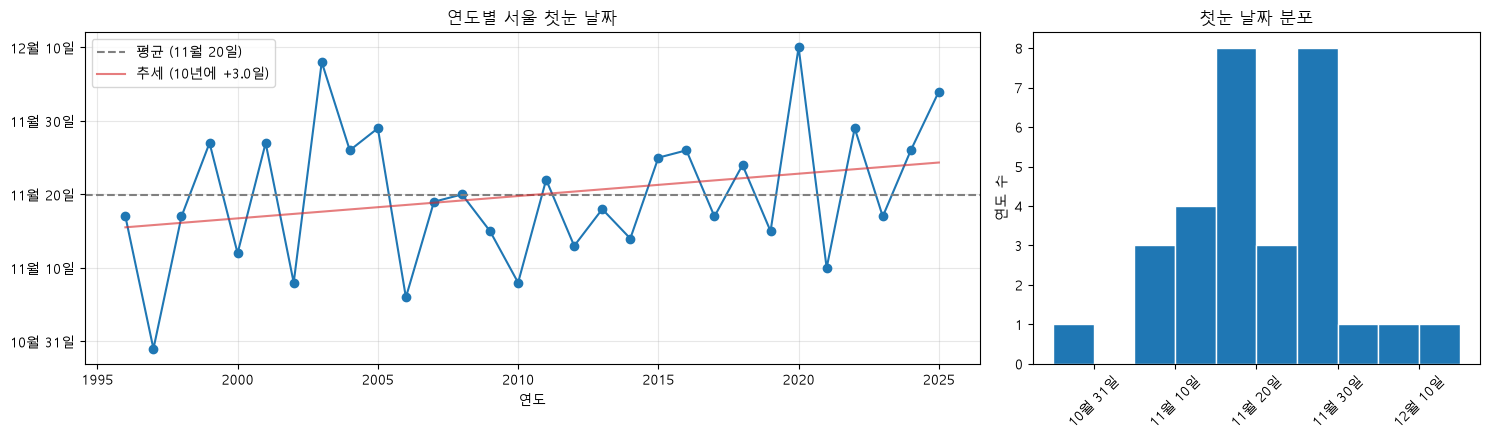

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})

# 왼쪽: 연도별 첫눈 날짜
ax = axes[0]
ax.plot(first_snow["연도"], y, marker="o")
ax.axhline(y.mean(), color="gray", linestyle="--", label=f"평균 ({to_date(y.mean())})")

# 추세선 (1차 직선)
slope, intercept = np.polyfit(first_snow["연도"], y, 1)
ax.plot(first_snow["연도"], slope * first_snow["연도"] + intercept,
        color="tab:red", alpha=0.6, label=f"추세 (10년에 {slope * 10:+.1f}일)")

# y축 눈금을 날짜로 표시
ticks = [60, 70, 80, 90, 100]
ax.set_yticks(ticks, [to_date(t) for t in ticks])
ax.set_title("연도별 서울 첫눈 날짜")
ax.set_xlabel("연도")
ax.legend()
ax.grid(alpha=0.3)

# 오른쪽: 첫눈 날짜 분포
ax = axes[1]
ax.hist(y, bins=range(55, 106, 5), edgecolor="white")
ax.set_xticks(ticks, [to_date(t) for t in ticks], rotation=45)
ax.set_title("첫눈 날짜 분포")
ax.set_ylabel("연도 수")

plt.tight_layout()
plt.show()

### 3-2. 가을 기온은 어떻게 떨어지나

9월 1일부터 12월 31일까지 매년의 일평균기온을 겹쳐 그리고, 각 연도의 첫눈 날을 점으로 표시한다.

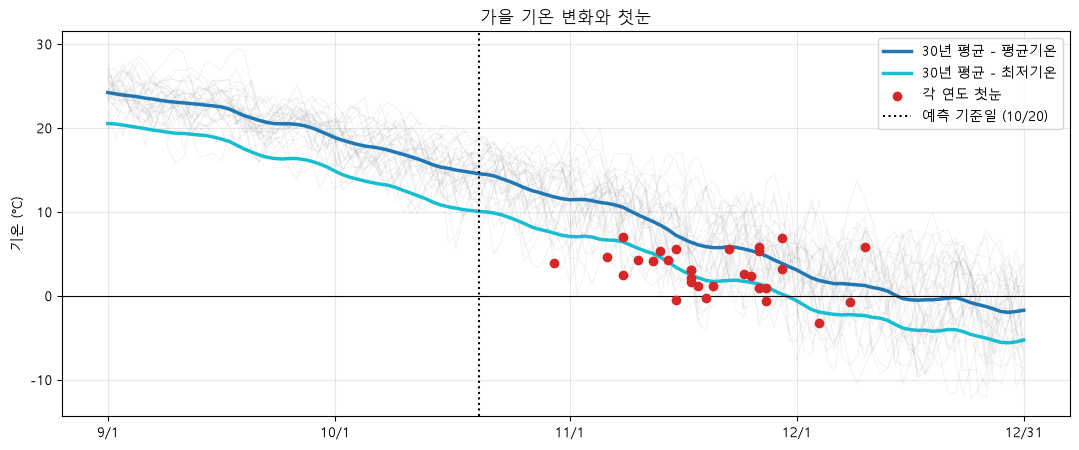

In [11]:
# 9~12월 데이터에 '9월 1일부터 며칠째' 컬럼 추가
fall = df[df["일시"].dt.month >= 9].copy()
fall["일수"] = (fall["일시"] - pd.to_datetime(fall["연도"].astype(str) + "-09-01")).dt.days

# 날짜별 30년 평균 (7일 이동평균으로 부드럽게)
clim = (
    fall.groupby("일수")[["평균기온(°C)", "최저기온(°C)"]].mean()
    .rolling(7, center=True, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(13, 5))

# 연도별 일평균기온 (옅은 회색)
for year, g in fall.groupby("연도"):
    ax.plot(g["일수"], g["평균기온(°C)"], color="gray", alpha=0.1, linewidth=0.8)

ax.plot(clim.index, clim["평균기온(°C)"], color="tab:blue", linewidth=2.5, label="30년 평균 - 평균기온")
ax.plot(clim.index, clim["최저기온(°C)"], color="tab:cyan", linewidth=2.5, label="30년 평균 - 최저기온")

# 첫눈 날 (그 날의 평균기온 위치)
ax.scatter(first_snow["첫눈_일수"], first_snow["평균기온(°C)"],
           color="tab:red", zorder=5, label="각 연도 첫눈")

ax.axvline(49, color="black", linestyle=":", label="예측 기준일 (10/20)")
ax.axhline(0, color="black", linewidth=0.8)

month_ticks = [0, 30, 61, 91, 121]
ax.set_xticks(month_ticks, ["9/1", "10/1", "11/1", "12/1", "12/31"])
ax.set_ylabel("기온 (°C)")
ax.set_title("가을 기온 변화와 첫눈")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.show()

### 3-3. 첫눈 전후의 기온 흐름

각 연도의 첫눈 날을 0일로 맞춘 뒤, 첫눈 30일 전부터 10일 후까지 기온이 어떻게 변하는지 평균을 낸다.
첫눈 직전에 기온이 갑자기 떨어지는지(한파가 들어오는지) 확인하기 위함이다.

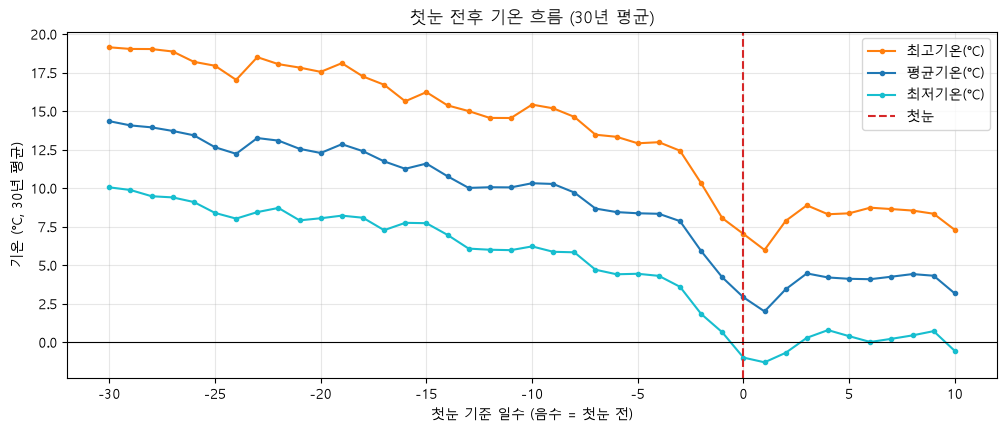

,평균기온(°C),최저기온(°C),최고기온(°C)
첫눈기준일,,,
-30,14.3,10.0,19.1
-14,10.8,7.0,15.4
-7,8.7,4.7,13.5
-3,7.9,3.6,12.4
-1,4.2,0.6,8.0
0,2.9,-1.0,7.0
1,2.0,-1.3,6.0
3,4.5,0.3,8.9
7,4.2,0.2,8.6


In [12]:
rows = []
for _, fs in first_snow.iterrows():
    window = df[(df["일시"] >= fs["일시"] - pd.Timedelta(days=30)) &
                (df["일시"] <= fs["일시"] + pd.Timedelta(days=10))].copy()
    window["첫눈기준일"] = (window["일시"] - fs["일시"]).dt.days
    rows.append(window)
around = pd.concat(rows)

aligned = around.groupby("첫눈기준일")[["평균기온(°C)", "최저기온(°C)", "최고기온(°C)"]].mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
for col, color in [("최고기온(°C)", "tab:orange"), ("평균기온(°C)", "tab:blue"), ("최저기온(°C)", "tab:cyan")]:
    ax.plot(aligned.index, aligned[col], marker=".", color=color, label=col)
ax.axvline(0, color="tab:red", linestyle="--", label="첫눈")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("첫눈 기준 일수 (음수 = 첫눈 전)")
ax.set_ylabel("기온 (°C, 30년 평균)")
ax.set_title("첫눈 전후 기온 흐름 (30년 평균)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

aligned.loc[[-30, -14, -7, -3, -1, 0, 1, 3, 7]].round(1)

### 3-4. 10월 20일까지의 기온이 첫눈과 관계가 있나

예측 시점(10/20)까지 알 수 있는 기온 정보가 첫눈 날짜와 관계가 있는지 산점도로 먼저 확인한다.

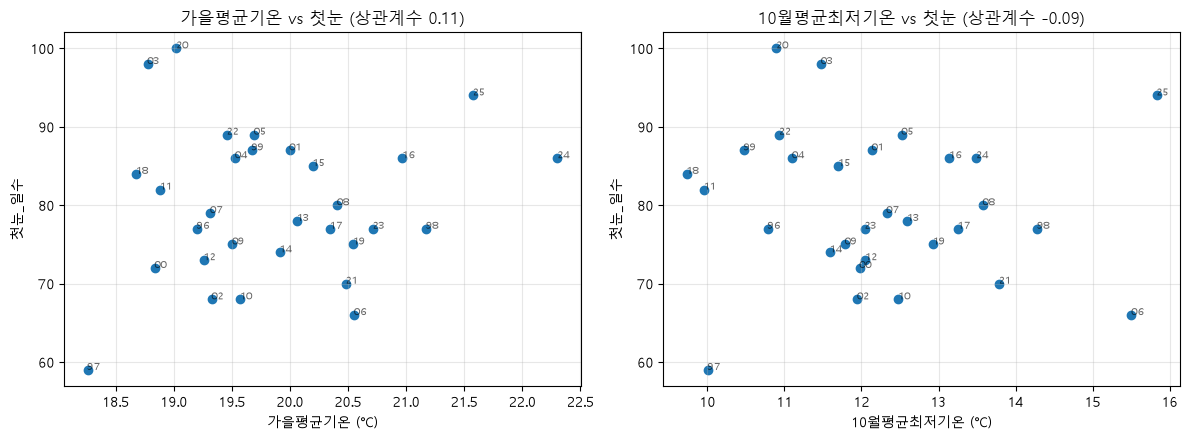

In [13]:
early = fall[fall["일수"] <= 49]                  # 9/1 ~ 10/20
early_oct = early[early["일시"].dt.month == 10]   # 10/1 ~ 10/20

check = (
    early.groupby("연도")["평균기온(°C)"].mean().rename("가을평균기온").to_frame()
    .join(early_oct.groupby("연도")["최저기온(°C)"].mean().rename("10월평균최저기온"))
    .reset_index()
    .merge(first_snow[["연도", "첫눈_일수"]], on="연도")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ["가을평균기온", "10월평균최저기온"]):
    r = check[col].corr(check["첫눈_일수"])
    ax.scatter(check[col], check["첫눈_일수"])
    for _, row in check.iterrows():
        ax.annotate(str(int(row["연도"]))[2:], (row[col], row["첫눈_일수"]), fontsize=7, alpha=0.6)
    ax.set_xlabel(f"{col} (°C)")
    ax.set_ylabel("첫눈_일수")
    ax.set_title(f"{col} vs 첫눈 (상관계수 {r:.2f})")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3단계 정리

**1. 첫눈 날짜 (3-1)**
- 평균 11월 20일, 표준편차 약 9.5일. 대부분 11월 10일 ~ 11월 30일 사이에 온다.
- 30년 동안 첫눈이 조금씩 늦어지는 경향이 있다 (10년에 약 +3일). 다만 해마다 편차가 커서 약한 경향이다.

**2. 첫눈은 '한파가 들이닥친 날' 온다 (3-2, 3-3)**
- 첫눈 3일 전부터 기온이 급격히 떨어진다. 평균기온이 약 8°C → 3°C로 사흘 만에 5°C 가까이 내려가고, 첫눈 날 최저기온은 평균 영하 1°C 정도다.
- 첫눈 이틀 뒤에는 기온이 다시 오른다 → 계절이 서서히 추워져서라기보다 **짧은 한파(찬 공기 유입)가 눈을 만든다.**
- 첫눈 날 기온(빨간 점)은 대부분 그 날짜의 30년 평균보다 낮다.

**3. 10월 20일까지의 기온은 첫눈과 거의 관계가 없다 (3-4)**
- 가을 평균기온과의 상관계수 0.11, 10월 평균최저기온과의 상관계수 -0.09.
- 첫눈을 만드는 한파는 예측 기준일(10/20)보다 한 달쯤 뒤에 오는 단기 현상이라, 가을 평균기온에는 그 신호가 거의 담기지 않는다.

**다음 단계에 주는 의미**
- 가을 날씨 평균만으로는 예측력이 낮을 가능성이 크다 → **기준선(평균으로 찍기)과의 비교가 꼭 필요하다.**
- 지금 보이는 가장 뚜렷한 신호는 **연도 추세**다. 기준선을 "평균" 하나만 두지 말고 "연도 추세만 쓴 예측"도 함께 비교해 볼 만하다.


## 4단계. 기준선 (Baseline)

**기준선이란?** 날씨 데이터를 전혀 보지 않고 "대충 찍었을 때" 나오는 오차다.
모델은 이 오차보다 작아야 날씨 데이터에서 뭔가를 배웠다고 말할 수 있다.

### 평가 방법: 과거로만 학습해서 다음 해 예측하기 (walk-forward)

실제로 예측하는 상황을 그대로 흉내 낸다. 예를 들어 2010년 첫눈을 예측할 때는 **2009년까지의 데이터만** 쓸 수 있다.

```
2006년 예측: 1996~2005 로 학습 → 2006 예측
2007년 예측: 1996~2006 로 학습 → 2007 예측
...
2025년 예측: 1996~2024 로 학습 → 2025 예측
```

- 처음 10년(1996~2005)은 학습용으로만 쓰고, **2006~2025년 20개 연도**의 예측 오차로 평가한다.
- 오차는 **MAE(평균 절대 오차)** = 예측이 실제 첫눈에서 평균 며칠 벗어났는지.
- 5·6단계의 모델도 똑같은 방법으로 평가해서 공정하게 비교한다.

In [14]:
TEST_START = 2006   # 이 연도부터 예측해서 평가


def walk_forward(data, predict_fn):
    """
    연도별로 '그 전 해까지의 데이터'로만 학습해서 그 해 첫눈_일수를 예측한다.

    data       : 연도, 첫눈_일수 (+ Feature) 컬럼이 있는 DataFrame
    predict_fn : (train, test_row) -> 예측값 을 돌려주는 함수
    """
    rows = []
    for year in data.loc[data["연도"] >= TEST_START, "연도"]:
        train = data[data["연도"] < year]
        test = data[data["연도"] == year]
        pred = predict_fn(train, test)
        rows.append({"연도": year, "실제": test["첫눈_일수"].iloc[0], "예측": pred})

    result = pd.DataFrame(rows)
    result["오차"] = result["예측"] - result["실제"]
    return result


def mae(result):
    return result["오차"].abs().mean()

### 기준선 3가지

| 기준선 | 예측 방법 | 의미 |
|---|---|---|
| ① 전체 평균 | 지금까지 모든 해의 평균 첫눈 날짜 | 가장 단순한 찍기 |
| ② 최근 10년 평균 | 직전 10년의 평균 첫눈 날짜 | 최근 기후를 더 반영 |
| ③ 연도 추세 | 연도 → 첫눈_일수 직선을 그어서 연장 | 3단계에서 본 "점점 늦어지는" 경향 반영 |

In [15]:
base_data = first_snow[["연도", "첫눈_일수"]]


# ① 전체 평균
def pred_mean(train, test):
    return train["첫눈_일수"].mean()


# ② 최근 10년 평균
def pred_recent10(train, test):
    return train["첫눈_일수"].tail(10).mean()


# ③ 연도 추세 (1차 직선)
def pred_trend(train, test):
    slope, intercept = np.polyfit(train["연도"], train["첫눈_일수"], 1)
    return slope * test["연도"].iloc[0] + intercept


baselines = {
    "① 전체 평균": walk_forward(base_data, pred_mean),
    "② 최근 10년 평균": walk_forward(base_data, pred_recent10),
    "③ 연도 추세": walk_forward(base_data, pred_trend),
}

summary = pd.DataFrame({
    "MAE(일)": {name: mae(r) for name, r in baselines.items()},
    "최대 오차(일)": {name: r["오차"].abs().max() for name, r in baselines.items()},
}).round(1)
summary

,MAE(일),최대 오차(일)
① 전체 평균,6.7,21.6
② 최근 10년 평균,6.9,21.8
③ 연도 추세,8.1,26.0


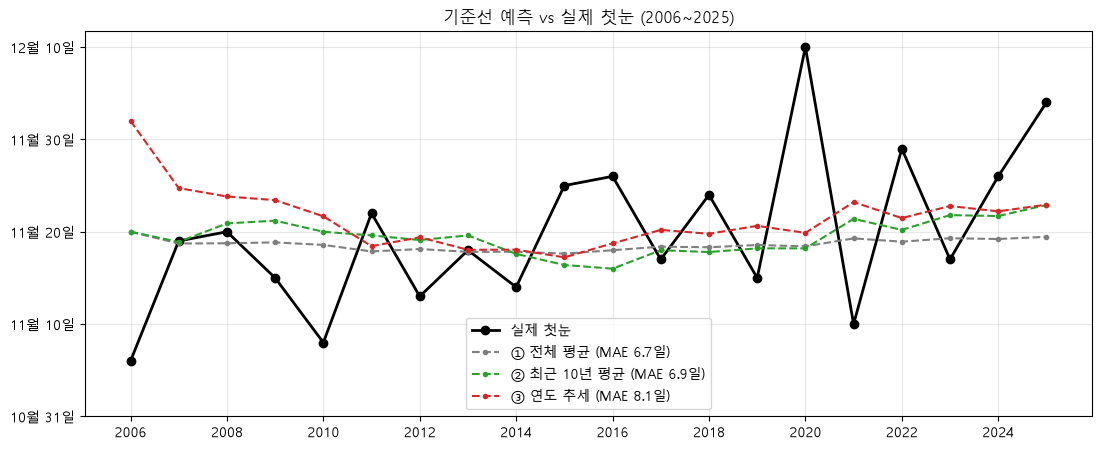

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))

actual = baselines["① 전체 평균"]
ax.plot(actual["연도"], actual["실제"], marker="o", color="black", linewidth=2, label="실제 첫눈")

for (name, r), color in zip(baselines.items(), ["tab:gray", "tab:green", "tab:red"]):
    ax.plot(r["연도"], r["예측"], marker=".", linestyle="--", color=color,
            label=f"{name} (MAE {mae(r):.1f}일)")

ticks = [60, 70, 80, 90, 100]
ax.set_yticks(ticks, [to_date(t) for t in ticks])
ax.set_xticks(range(TEST_START, 2026, 2))
ax.set_title("기준선 예측 vs 실제 첫눈 (2006~2025)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 4단계 정리

| 기준선 | MAE | 최대 오차 |
|---|---|---|
| ① 전체 평균 | **6.7일** | 21.6일 |
| ② 최근 10년 평균 | 6.9일 | 21.8일 |
| ③ 연도 추세 | 8.1일 | 26.0일 |

- **가장 좋은 기준선은 ① 전체 평균 (MAE 6.7일).** 앞으로 만들 모델은 **6.7일보다 작아야** 의미가 있다.
- ③ 연도 추세는 오히려 가장 나빴다. 학습 데이터가 10년뿐인 초반(2006~2010)에 직선이 크게 기울어 11월 말을 예측했기 때문이다. 데이터가 쌓인 최근 10년(2016~2025)만 보면 평균(8.3일)과 추세(8.2일)가 거의 같다 → 추세는 있어도 예측에 도움이 될 만큼 뚜렷하지 않다.
- 모든 기준선이 2006년(11/6), 2010년(11/8), 2020년(12/10), 2021년(11/10)처럼 **평균에서 크게 벗어난 해**를 전혀 맞히지 못한다. 모델이 기준선을 이기려면 이런 해를 어느 정도 맞혀야 한다.


## 5단계. 1부 결론 - 가을 날씨로 첫눈 날짜를 미리 예측하기는 어렵다

- 첫눈은 평균 11월 20일에 오지만 해마다 ±9.5일 정도 차이가 난다.
- 10월 20일까지의 기온은 첫눈 날짜와 거의 관계가 없다 (상관계수 약 ±0.1).
- 첫눈은 서서히 추워져서가 아니라 **며칠짜리 짧은 한파**가 들어온 날 온다. 이 한파는 예측 기준일보다 한 달쯤 뒤의 일이라 가을 날씨에는 신호가 남지 않는다.
- 가장 좋은 기준선(전체 평균)의 오차가 6.7일인데, 가을 날씨로 이보다 크게 나아지기는 어려워 보인다.

→ 질문을 바꾼다. **"언제 올까?" 대신 "어떤 조건이면 눈이 오나?"**

# 2부. 첫눈이 올 수 있는 조건

## 6단계. 분석 대상 정하기

눈이 오려면 먼저 **하늘에서 뭔가 내려야(강수)** 한다. 그래서 비교 대상을 **"비나 눈이 온 날"**로 한정하고,
그중 **눈이 온 날 vs 비만 온 날**을 가르는 조건을 찾는다.

- 기간: 10~12월 (첫눈이 오는 시기)
- 강수일: 기사에 비·이슬비·소나기 또는 눈 계열 현상이 기록된 날
  (`일강수량`은 눈이 조금 날린 날 0으로 기록되는 경우가 있어서 기사로 판단한다)
- 눈 온 날: 기사에 눈 계열 현상이 있는 날 (비와 눈이 같이 온 날 포함)

In [17]:
RAIN_PATTERN = r"\{(?:비|이슬비|소나기|눈|진눈깨비|소낙눈|싸락눈|가루눈|소낙성진눈깨비)\}"
df["강수"] = df["기사"].str.contains(RAIN_PATTERN, regex=True)

# 추가로 비교해 볼 변수
# - 3일전대비: 3일 전보다 평균기온이 얼마나 변했는지 (음수 = 추워짐)
# - 북서풍: 가장 많이 분 바람이 북서쪽(250~340도)에서 왔는지 → 대륙의 찬 공기
df["3일전대비"] = df["평균기온(°C)"].diff(3)
df["북서풍"] = df["최다풍향(16방위)"].between(250, 340)

precip = df[df["일시"].dt.month.isin([10, 11, 12]) & df["강수"]].copy()
precip["구분"] = np.where(precip["눈"], "눈", "비만")

print("10~12월 강수일:", len(precip))
precip["구분"].value_counts()

10~12월 강수일: 931


구분
비만    662
눈     269
Name: count, dtype: int64

## 7단계. 눈 온 날 vs 비만 온 날 비교

In [18]:
compare_cols = ["평균기온(°C)", "최저기온(°C)", "최고기온(°C)", "평균 이슬점온도(°C)",
                "평균 상대습도(%)", "평균 해면기압(hPa)", "3일전대비", "평균 풍속(m/s)"]

# 각 변수의 중앙값 비교
precip.groupby("구분")[compare_cols].median().T.round(1)

구분,눈,비만
평균기온(°C),-0.4,10.7
최저기온(°C),-3.9,7.0
최고기온(°C),3.1,14.6
평균 이슬점온도(°C),-7.3,5.1
평균 상대습도(%),62.4,71.1
평균 해면기압(hPa),1023.1,1018.3
3일전대비,-1.6,0.2
평균 풍속(m/s),2.4,2.3


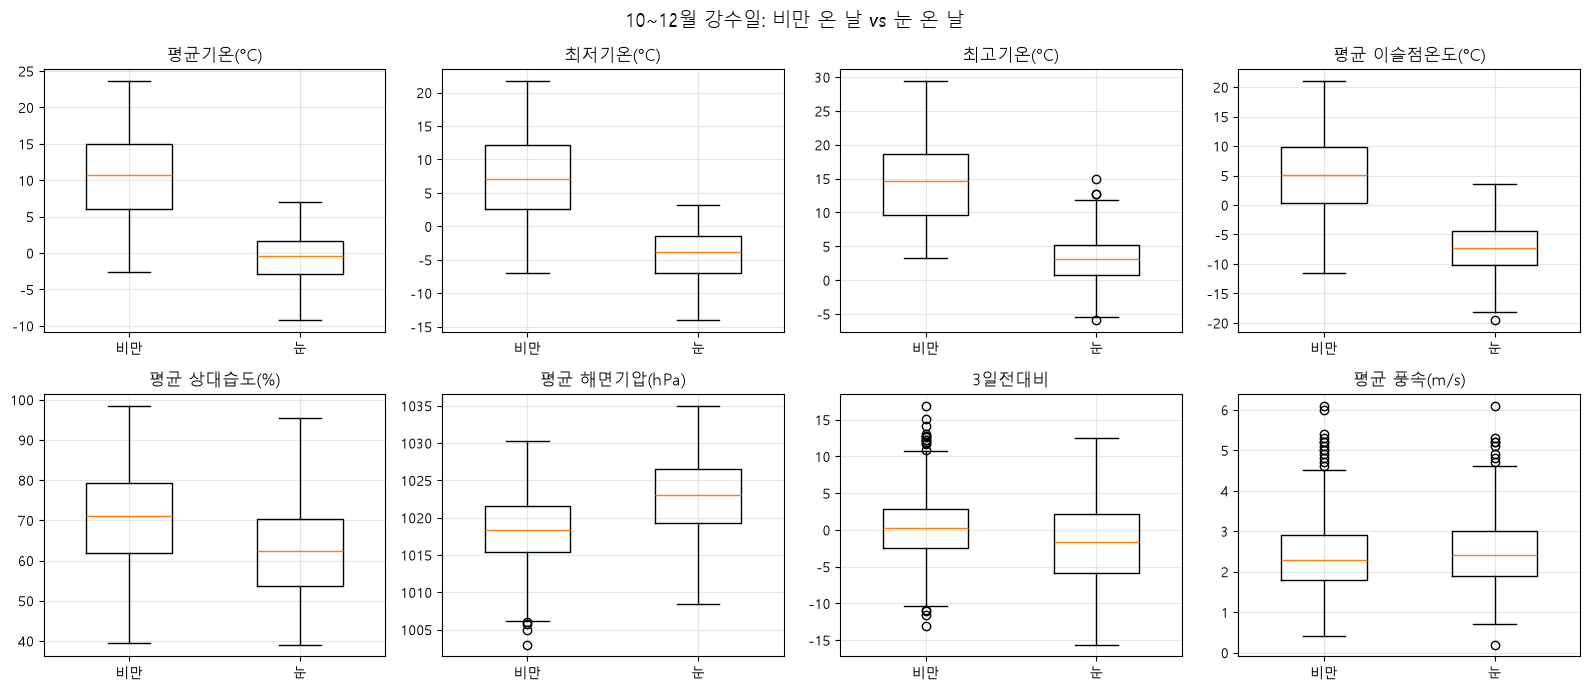

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, compare_cols):
    data = [precip.loc[precip["구분"] == k, col].dropna() for k in ["비만", "눈"]]
    ax.boxplot(data, tick_labels=["비만", "눈"], widths=0.5)
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.suptitle("10~12월 강수일: 비만 온 날 vs 눈 온 날", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# 바람: 가장 많이 분 바람의 방향별 비율
wind = pd.crosstab(precip["구분"], precip["북서풍"], normalize="index").round(2)
wind.columns = ["북서풍 아님", "북서풍"]
wind

,북서풍 아님,북서풍
구분,,
눈,0.42,0.58
비만,0.63,0.37


## 8단계. 기온별 눈 확률

기온을 2°C 구간으로 나누고, 각 구간의 강수일 중 **눈이 온 날의 비율**을 구한다.
확률이 50%가 되는 기온이 "비와 눈의 경계"다.

최저기온(°C): 눈 확률 50% ≈ -0.8°C
평균기온(°C): 눈 확률 50% ≈ 2.4°C
최고기온(°C): 눈 확률 50% ≈ 5.8°C


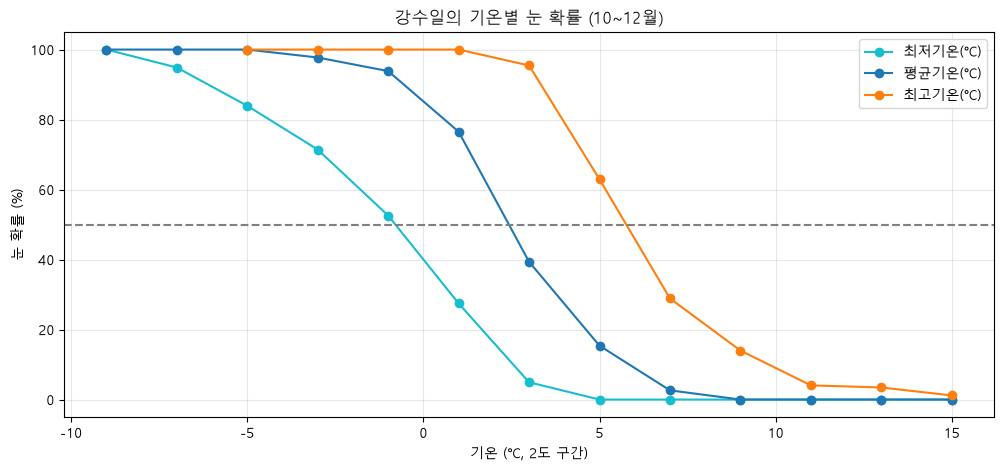

In [21]:
bins = range(-10, 17, 2)
temp_cols = ["최저기온(°C)", "평균기온(°C)", "최고기온(°C)"]

fig, ax = plt.subplots(figsize=(12, 5))
prob_tables = {}
for col, color in zip(temp_cols, ["tab:cyan", "tab:blue", "tab:orange"]):
    grp = precip.groupby(pd.cut(precip[col], bins), observed=True)["눈"].agg(["mean", "size"])
    grp = grp[grp["size"] >= 5]          # 날이 너무 적은 구간은 제외
    mids = [iv.mid for iv in grp.index]
    ax.plot(mids, grp["mean"] * 100, marker="o", color=color, label=col)
    prob_tables[col] = grp

    # 확률이 50%를 지나는 기온 (직선 보간)
    x50 = np.interp(0.5, grp["mean"].values[::-1], np.array(mids)[::-1])
    print(f"{col}: 눈 확률 50% ≈ {x50:.1f}°C")

ax.axhline(50, color="gray", linestyle="--")
ax.set_xlabel("기온 (°C, 2도 구간)")
ax.set_ylabel("눈 확률 (%)")
ax.set_title("강수일의 기온별 눈 확률 (10~12월)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [22]:
# 평균기온 구간별 표
t = prob_tables["평균기온(°C)"].copy()
t["눈 확률(%)"] = (t["mean"] * 100).round(0)
t.rename(columns={"size": "강수일 수"})[["강수일 수", "눈 확률(%)"]]

,강수일 수,눈 확률(%)
평균기온(°C),,
"(-10, -8]",6,100.0
"(-8, -6]",14,100.0
"(-6, -4]",28,100.0
"(-4, -2]",44,98.0
"(-2, 0]",65,94.0
"(0, 2]",81,77.0
"(2, 4]",94,39.0
"(4, 6]",104,15.0
"(6, 8]",76,3.0


## 9단계. 비와 눈이 섞이는 경계 구간

평균기온 0~6°C 구간은 비가 올 수도, 눈이 올 수도 있다.
이 구간에서 **기온 말고 무엇이** 비와 눈을 가르는지 확인한다.

In [23]:
border = precip[precip["평균기온(°C)"].between(0, 6)]
print("경계 구간 강수일:", len(border), "/ 눈 비율:", round(border["눈"].mean() * 100), "%")

border.groupby("구분")[["평균기온(°C)", "최저기온(°C)", "평균 이슬점온도(°C)",
                         "평균 상대습도(%)", "3일전대비"]].mean().T.round(2)

경계 구간 강수일: 283 / 눈 비율: 42 %


구분,눈,비만
평균기온(°C),2.08,4.00
최저기온(°C),-1.36,0.31
평균 이슬점온도(°C),-4.28,-2.26
평균 상대습도(%),64.87,65.67
3일전대비,-0.67,0.23


In [24]:
# 이슬점(공기 중 수증기량)별 눈 확률 - 경계 구간 안에서
dew_bins = [-20, -6, -3, 0, 10]
dew = border.groupby(pd.cut(border["평균 이슬점온도(°C)"], dew_bins), observed=True)["눈"].agg(["mean", "size"])
dew["눈 확률(%)"] = (dew["mean"] * 100).round(0)
dew.rename(columns={"size": "강수일 수"})[["강수일 수", "눈 확률(%)"]]

,강수일 수,눈 확률(%)
평균 이슬점온도(°C),,
"(-20, -6]",57,61.0
"(-6, -3]",84,57.0
"(-3, 0]",87,30.0
"(0, 10]",55,18.0


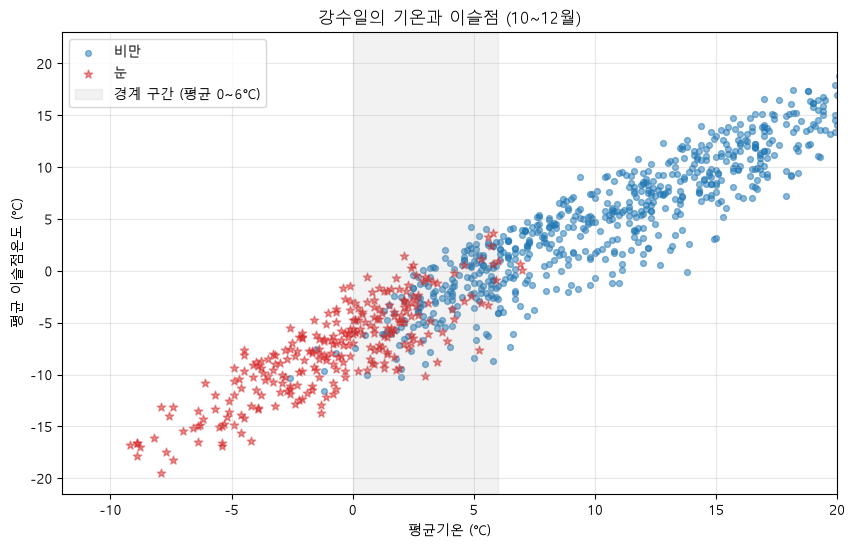

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
for k, color, marker in [("비만", "tab:blue", "o"), ("눈", "tab:red", "*")]:
    sub = precip[precip["구분"] == k]
    ax.scatter(sub["평균기온(°C)"], sub["평균 이슬점온도(°C)"], s=18 if k == "비만" else 40,
               alpha=0.5, color=color, marker=marker, label=k)
ax.axvspan(0, 6, color="gray", alpha=0.1, label="경계 구간 (평균 0~6°C)")
ax.set_xlabel("평균기온 (°C)")
ax.set_ylabel("평균 이슬점온도 (°C)")
ax.set_title("강수일의 기온과 이슬점 (10~12월)")
ax.set_xlim(-12, 20)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 10단계. 조건을 첫눈에 적용해 보기

8단계에서 찾은 기온 경계를 이용해, 매년 **"강수가 있고 평균기온이 기준 이하인 첫 날"**을 뽑아
실제 첫눈 날짜와 비교한다. 조건이 첫눈을 잘 설명한다면 두 날짜가 비슷해야 한다.

In [26]:
autumn = df[df["일시"].dt.month >= 9]
actual = first_snow.set_index("연도")["일시"]

rows = []
for thr in [2, 3, 4, 5]:
    cond = (autumn[autumn["강수"] & (autumn["평균기온(°C)"] <= thr)]
            .drop_duplicates("연도").set_index("연도")["일시"])
    diff = (cond - actual).dt.days.reindex(actual.index)
    rows.append({
        "조건": f"강수 & 평균기온 ≤ {thr}°C",
        "첫눈과 같은 날": f"{(diff == 0).sum()}/30",
        "평균 차이(일)": round(diff.abs().mean(), 1),
        "조건일이 먼저": (diff < 0).sum(),
        "첫눈이 먼저": (diff > 0).sum(),
    })
pd.DataFrame(rows)

,조건,첫눈과 같은 날,평균 차이(일),조건일이 먼저,첫눈이 먼저
0,강수 & 평균기온 ≤ 2°C,9/30,8.3,1,19
1,강수 & 평균기온 ≤ 3°C,14/30,5.4,2,13
2,강수 & 평균기온 ≤ 4°C,16/30,4.7,3,11
3,강수 & 평균기온 ≤ 5°C,18/30,3.0,6,6


In [27]:
# 평균기온 4°C 기준으로 연도별 비교
THR = 4
cond = (autumn[autumn["강수"] & (autumn["평균기온(°C)"] <= THR)]
        .drop_duplicates("연도").set_index("연도")["일시"])
check4 = pd.DataFrame({"실제 첫눈": actual, f"조건 충족 첫날(≤{THR}°C)": cond})
check4["차이(일)"] = (check4.iloc[:, 1] - check4.iloc[:, 0]).dt.days

# 조건보다 첫눈이 먼저 온 해: 그날 날씨
early = first_snow.set_index("연도").loc[check4.index[check4["차이(일)"] > 0],
                                         ["일시", "평균기온(°C)", "최저기온(°C)", "기사"]]
display(check4)
print(f"\n조건(≤{THR}°C)보다 첫눈이 먼저 온 해의 첫눈 날 날씨")
early

,실제 첫눈,조건 충족 첫날(≤4°C),차이(일)
연도,,,
1996,1996-11-17,1996-11-17,0
1997,1997-10-30,1997-10-30,0
1998,1998-11-17,1998-11-17,0
1999,1999-11-27,1999-11-27,0
2000,2000-11-12,2000-12-03,21
2001,2001-11-27,2001-11-27,0
2002,2002-11-08,2002-11-08,0
2003,2003-12-08,2003-12-06,-2
2004,2004-11-26,2004-12-06,10



조건(≤4°C)보다 첫눈이 먼저 온 해의 첫눈 날 날씨


,일시,평균기온(°C),최저기온(°C),기사
연도,,,,
2000,2000-11-12,4.1,-0.5,{진눈깨비}0638-0652.
2004,2004-11-26,5.3,1.7,-{비}-{비}{강도0}0300-{비}{강도1}0600-グ0845-グ{강도0}090...
2006,2006-11-06,4.6,-0.1,-{비}-0040. {비}0110-0255. {비}0520-{비}{강도0}0600-...
2010,2010-11-08,7.0,1.8,-{비}-0110. {비}0335-0345. {비}0403-0430. {비}0455...
2011,2011-11-22,5.6,1.9,{비}0445-{이슬비}0505-{싸락눈}0510-0520. {비}1610-1630...
2012,2012-11-13,5.3,1.7,{비}1505-1515. {눈}2255-2315.
2014,2014-11-14,4.2,-1.4,{눈}0340-0410. {박무}0349-0446.
2019,2019-11-15,5.6,1.4,{진눈깨비}0150-{비}0240-{비}{강도0}0300-0315. {비}0510-...
2021,2021-11-10,4.2,0.7,{눈}0610-{진눈깨비}0645-0850. {박무}0635-0710. {비}174...


### 10-2. 최저기온 기준으로 다시 확인

위에서 조건보다 첫눈이 먼저 온 해는 대부분 **새벽에 잠깐 눈이 온 날**이었고, 그날 최저기온은 모두 2°C 이하였다.
그래서 평균기온 대신 **최저기온**으로 조건을 다시 만들어 비교한다.

조건이 좋은지는 두 가지 방향으로 본다.

| 지표 | 뜻 | 높으면 |
|---|---|---|
| **정밀도** | 조건을 만족한 강수일 중 실제로 눈이 온 비율 | 조건이 "눈 온다"고 할 때 잘 맞는다 |
| **재현율** | 실제 눈 온 날 중 조건을 만족한 비율 | 눈 온 날을 빠뜨리지 않는다 |

그리고 첫눈에 적용했을 때 실제 첫눈 날짜와 얼마나 가까운지도 함께 본다. (9~12월 강수일 기준)

In [28]:
autumn_precip = autumn[autumn["강수"]]


def evaluate_rule(name, mask):
    """강수일에 조건(mask)을 적용해서 정밀도·재현율과 첫눈 날짜 일치도를 계산한다."""
    hit = autumn_precip[mask]
    precision = hit["눈"].mean()
    recall = hit["눈"].sum() / autumn_precip["눈"].sum()

    cond_first = hit.drop_duplicates("연도").set_index("연도")["일시"]
    diff = (cond_first - actual).dt.days.reindex(actual.index)
    return {
        "조건": name,
        "정밀도(%)": round(precision * 100),
        "재현율(%)": round(recall * 100),
        "첫눈과 같은 날": (diff == 0).sum(),
        "평균 차이(일)": round(diff.abs().mean(), 1),
        "조건일이 먼저": (diff < 0).sum(),
        "첫눈이 먼저": (diff > 0).sum(),
        "최대 차이(일)": diff.abs().max(),
    }


tmin = autumn_precip["최저기온(°C)"]
tavg = autumn_precip["평균기온(°C)"]
dew = autumn_precip["평균 이슬점온도(°C)"]

rules = [evaluate_rule(f"최저기온 ≤ {t}°C", tmin <= t) for t in [-2, -1, 0, 1, 2, 3]]
rules += [evaluate_rule(f"평균기온 ≤ {t}°C", tavg <= t) for t in [3, 4, 5]]
rules += [evaluate_rule("최저기온 ≤ 2°C & 이슬점 ≤ -3°C", (tmin <= 2) & (dew <= -3))]

rule_table = pd.DataFrame(rules).set_index("조건")
rule_table

,정밀도(%),재현율(%),첫눈과 같은 날,평균 차이(일),조건일이 먼저,첫눈이 먼저,최대 차이(일)
조건,,,,,,,
최저기온 ≤ -2°C,85,70,7,10.0,2,21,41.0
최저기온 ≤ -1°C,81,81,11,7.3,3,16,39.0
최저기온 ≤ 0°C,75,89,15,5.0,5,10,39.0
최저기온 ≤ 1°C,69,96,18,3.9,7,5,26.0
최저기온 ≤ 2°C,65,99,20,4.6,10,0,41.0
최저기온 ≤ 3°C,59,100,14,7.1,16,0,41.0
평균기온 ≤ 3°C,82,90,14,5.4,2,13,24.0
평균기온 ≤ 4°C,76,93,16,4.7,3,11,24.0
평균기온 ≤ 5°C,69,96,18,3.0,6,6,24.0


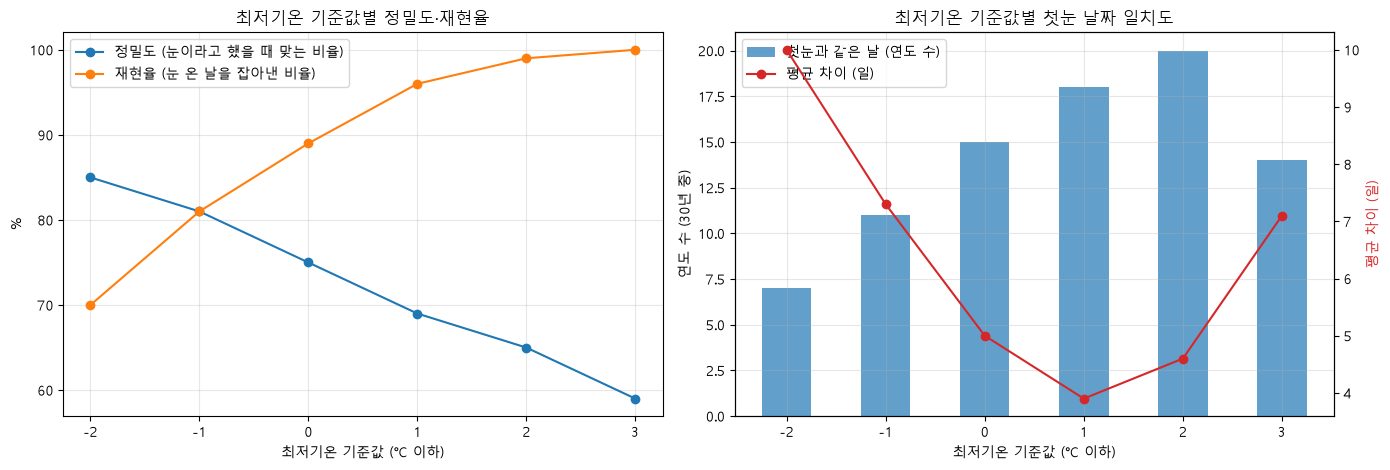

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# 왼쪽: 최저기온 기준값에 따른 정밀도 / 재현율
t_only = rule_table.loc[[f"최저기온 ≤ {t}°C" for t in [-2, -1, 0, 1, 2, 3]]]
xs = [-2, -1, 0, 1, 2, 3]
ax = axes[0]
ax.plot(xs, t_only["정밀도(%)"], marker="o", label="정밀도 (눈이라고 했을 때 맞는 비율)")
ax.plot(xs, t_only["재현율(%)"], marker="o", label="재현율 (눈 온 날을 잡아낸 비율)")
ax.set_xlabel("최저기온 기준값 (°C 이하)")
ax.set_ylabel("%")
ax.set_title("최저기온 기준값별 정밀도·재현율")
ax.legend()
ax.grid(alpha=0.3)

# 오른쪽: 첫눈 날짜와의 일치
ax = axes[1]
bars = ax.bar(xs, t_only["첫눈과 같은 날"], width=0.5, alpha=0.7, label="첫눈과 같은 날 (연도 수)")
ax2 = ax.twinx()
line, = ax2.plot(xs, t_only["평균 차이(일)"], marker="o", color="tab:red", label="평균 차이 (일)")
ax.set_xlabel("최저기온 기준값 (°C 이하)")
ax.set_ylabel("연도 수 (30년 중)")
ax2.set_ylabel("평균 차이 (일)", color="tab:red")
ax.set_title("최저기온 기준값별 첫눈 날짜 일치도")
ax.legend(handles=[bars, line], loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# 최저기온 ≤ 1°C 조건으로 연도별 비교 - 차이가 큰 해 살펴보기
TMIN = 1
cond = (autumn_precip[autumn_precip["최저기온(°C)"] <= TMIN]
        .drop_duplicates("연도").set_index("연도"))
check_min = pd.DataFrame({
    "실제 첫눈": actual,
    f"조건 충족 첫날(최저≤{TMIN}°C)": cond["일시"],
    "그날 최저기온": cond["최저기온(°C)"],
    "그날 기사": cond["기사"].str.slice(0, 60),
})
check_min["차이(일)"] = (check_min.iloc[:, 1] - check_min.iloc[:, 0]).dt.days

print(f"첫눈과 같은 날: {(check_min['차이(일)'] == 0).sum()}/30")
print("차이가 3일 넘는 해:")
check_min[check_min["차이(일)"].abs() > 3]

첫눈과 같은 날: 18/30
차이가 3일 넘는 해:


,실제 첫눈,조건 충족 첫날(최저≤1°C),그날 최저기온,그날 기사,차이(일)
연도,,,,,
2004,2004-11-26,2004-12-06,-2.2,{비}1846-{비}{강도0}2100-2215. {박무}1935-{박무}{강도0}...,10
2010,2010-11-08,2010-11-27,-2.7,{얼음싸라기}0610-0645. {얼음싸라기}0715-{싸락눈}0728-0740. ...,19
2016,2016-11-26,2016-10-31,0.7,{비}0625-{비}{강도0}0900-0925. {비}1010-1045. {비}12...,-26
2018,2018-11-24,2018-10-30,0.7,{비}2225-{비}{강도0}2400-,-25
2020,2020-12-10,2020-11-20,0.3,-{비}-0240. {비}0330-0520.,-20
2025,2025-12-04,2025-11-29,0.3,{비}2040-2055. {비}2110-2350.,-5


### 10-2 정리

**1. 최저기온 2°C는 눈의 '필수 조건'에 가깝다**
- 눈 온 날의 **99%**가 최저기온 2°C 이하였다 (재현율 99%).
- 이 조건보다 첫눈이 먼저 온 해는 **30년 중 한 번도 없다** ("첫눈이 먼저" = 0).
- → **최저기온이 2°C 아래로 내려가기 전에는 첫눈이 오지 않는다.**
- 다만 이 조건을 만족해도 35%는 비만 왔다 (정밀도 65%). 필요하지만 충분하지는 않은 조건이다.

**2. 첫눈 날짜와의 일치도는 최저기온 ≤ 1°C와 평균기온 ≤ 5°C가 비슷하다**
- 최저기온 ≤ 1°C: 30년 중 **18년** 같은 날, 평균 차이 3.9일
- 평균기온 ≤ 5°C: 30년 중 **18년** 같은 날, 평균 차이 **3.0일**
- 날짜만 보면 둘이 비슷하다 (평균 차이는 평균기온 조건이 조금 더 작다). 평균기온도 기준을 5°C까지 올리면 새벽에 잠깐 오는 첫눈을 잡을 수 있기 때문이다.
- 최저기온 기준의 장점은 날짜가 더 잘 맞는 것이 아니라 **해석이 명확하다**는 점이다. "최저기온 2°C 아래로 떨어지기 전에는 첫눈이 오지 않는다"는 필수 조건을 준다.
- 기준값을 낮추면(≤ -2°C) 조건이 정확해지지만(정밀도 85%) 첫눈을 늦게 잡고, 높이면(≤ 3°C) 비 오는 날까지 잡아서 너무 일찍 잡는다.

**3. 그래도 틀리는 경우 - 하루 단위 데이터의 한계**
- 2016·2018·2020년: 조건은 10월 말~11월에 만족했지만 비만 왔다. 기사를 보면 비는 밤에 왔는데 최저기온은 다른 시간(보통 새벽)에 찍혔다. **"추웠던 시간"과 "비가 온 시간"이 달랐던 것이다.**
- 2004·2010년: 첫눈 날 최저기온이 1.7~1.8°C로 기준보다 살짝 높았다.
- 시간별 기온과 강수 자료가 있으면 이 한계를 줄일 수 있다.

**4. 이슬점을 같이 쓰면?**
- "최저 ≤ 2°C & 이슬점 ≤ -3°C"는 정밀도가 79%로 오르지만, 눈 온 날을 16% 놓치고 첫눈 일치는 17년으로 오히려 줄었다.
- 첫눈 날짜를 찾는 목적에서는 최저기온 하나가 더 단순하고 잘 맞는다.


## 11단계. 2부 결론 - 첫눈이 올 수 있는 조건

**1. 가장 중요한 조건은 기온이다 (8단계)**

비나 눈이 내린 날 중 눈일 확률이 50%가 되는 기온:

| 기준 | 눈 확률 50% 기온 |
|---|---|
| 최저기온 | 약 -1°C |
| 평균기온 | 약 2.4°C |
| 최고기온 | 약 6°C |

- 평균기온 0°C 이하 → 94~100% 눈
- 평균기온 0~2°C → 77% / 2~4°C → 39% / 4~6°C → 15%
- 평균기온 8°C 이상 → 눈이 온 적 없음

**2. 눈 오는 날은 '차고 건조한 북서풍 공기'가 들어온 날이다 (7단계)**
- 이슬점이 훨씬 낮다 (눈 -7.3°C vs 비 5.1°C) → 공기가 건조하다
- 기압이 높다 (1023 vs 1018 hPa) → 시베리아 고기압의 영향
- 북서풍 비율이 높다 (58% vs 37%) → 대륙에서 찬 공기가 내려옴
- 3일 전보다 기온이 떨어져 있다 (-1.6°C) → 한파 유입 (1부 3-3단계와 같은 결과)

**3. 비와 눈이 섞이는 평균 0~6°C 구간에서는 '건조함'이 눈을 가른다 (9단계)**
- 같은 기온대라도 이슬점이 -3°C 이하면 눈 확률 약 60%, 0°C 이상이면 18%
- 공기가 건조하면 떨어지는 눈이 증발하며 주변을 식혀서, 녹지 않고 눈으로 내린다

**4. 조건을 첫눈에 적용하면 (10단계)**
- **최저기온 2°C 이하는 눈의 필수 조건에 가깝다.** 눈 온 날의 99%가 이 조건을 만족했고, 이 조건보다 첫눈이 먼저 온 해는 30년 중 한 번도 없었다.
- 첫눈 날짜와의 일치도는 **"강수 & 최저기온 ≤ 1°C"**(18년 같은 날, 평균 3.9일 차이)와 **"강수 & 평균기온 ≤ 5°C"**(18년, 평균 3.0일)가 비슷하게 가장 좋았다.
- 첫눈은 새벽처럼 하루 중 가장 추운 시간에 잠깐 오는 경우가 많다. 그래서 평균기온으로 잡으려면 기준을 5°C까지 넉넉히 올려야 한다.
- 틀리는 해는 대부분 "추웠던 시간"과 "비가 온 시간"이 달랐던 경우로, 하루 단위 자료의 한계다.
- (이 조건들은 **당일 날씨**를 알아야 쓸 수 있으므로, 몇 주 전에 미리 예측하는 것과는 다르다.)

**한 줄 요약**
> 서울의 첫눈은 **비나 눈이 내리는 날, 최저기온이 1~2°C 아래로 떨어지고, 북서풍을 타고 차고 건조한 공기가 들어올 때** 온다.
> 이런 날은 몇 주 전에는 알 수 없지만, 며칠 전 일기예보(기온·강수)로는 첫눈 가능성을 판단할 수 있다.
